### Examining the output of T-Route at the Taylor Dam, Colorado using Channel Loss
#### Author: Tadd Bindas

In the following lines of this notebook, we will plot the output of a T-Route run with inputs taken from a NGEN run using initial versions (uncalibrated) CFE + NOAH-OWP-Modular + Evapotranspiration to see how t-route works with and without the channel loss algorithm. 

The algorithm implemented in T-route is from the following site: https://www.weather.gov/media/owp/oh/hrl/docs/533chanloss.pdf

where
```
Q = Q - SSOUT  # Subsurface outflow
```
and
```
E = ET * PEADJ
ELOSS = E * 0.27778/TIMINT * (dx * tw)
Q = Q - ELOSS 
```
where ET is directly taken from NGEN outputs from the evapotranspiration module and TIMINT is 1 to represent hourly

*NOTE* to run this code, you will need to have run the following commands with all YAML files in this folder. That includes the following commands:
```sh
python -m nwm_routing -f -V4 taylor_dam.yaml
python -m nwm_routing -f -V4 taylor_dam_eloss_base.yaml
python -m nwm_routing -f -V4 taylor_dam_eloss_high.yaml
python -m nwm_routing -f -V4 taylor_dam_ssout_base.yaml
python -m nwm_routing -f -V4 taylor_dam_ssout_high.yaml
```
This ensures that you are running the model both with and without Channel Loss (both the ELOSS and SSOUT)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import geopandas as gpd


Let"s plot / examine the sample basin to see where we"re modeling. You can see the tile of the Taylor Lake on the middle-right of the output

In [2]:
lakes = gpd.read_file("./domain/09112500.gpkg", layer="lakes")
divides = gpd.read_file("./domain/09112500.gpkg", layer="divides")
nexus = gpd.read_file("./domain/09112500.gpkg", layer="nexus")
fp = gpd.read_file("./domain/09112500.gpkg", layer="flowpaths")


In [3]:
divide_ex = divides.explore(color="grey", tiles="OpenStreetMap")
lakes_ex = lakes.explore(m=divide_ex, color="blue")
nexus_ex = nexus.explore(m=lakes_ex, color="black")
fp.explore(m=nexus_ex, color="orange")


#### Examining ELOSS

first, we'll examine the differences between running with and without the ELOSS. Two different PEADJ values are shown to denonstrate how the adjustment setting is used.

In [4]:
# Load t-route output datasets for 
ds = xr.open_dataset("./output/base_output/troute_output_202208020000.nc", engine="netcdf4")
ds_base_eloss = xr.open_dataset("./output/eloss_base/troute_output_202208020000.nc", engine="netcdf4") 
ds_high_eloss = xr.open_dataset("./output/eloss_high/troute_output_202208020000.nc", engine="netcdf4")


In [5]:
# Process base model stream data at the downstream-most nexus
df = ds.sel(feature_id=2619318).to_dataframe().reset_index()
df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time")
df["flow"] = df["flow"] * 0.028316846592 # convert to cms

# Process channel loss (ET) stream data at the downstream-most nexus
df_base_eloss = ds_base_eloss.sel(feature_id=2619318).to_dataframe().reset_index()
df_base_eloss["time"] = pd.to_datetime(df_base_eloss["time"])
df_base_eloss = df_base_eloss.set_index("time")
df_base_eloss["flow"] = df_base_eloss["flow"] * 0.028316846592 # convert to cms

df_high_eloss = ds_high_eloss.sel(feature_id=2619318).to_dataframe().reset_index()
df_high_eloss["time"] = pd.to_datetime(df_high_eloss["time"])
df_high_eloss = df_high_eloss.set_index("time")
df_high_eloss["flow"] = df_high_eloss["flow"] * 0.028316846592 # convert to cms


In [ ]:
# Process ELOSS outputs for plotting losses
eloss_base_vals = pd.read_csv("./channel_forcing/et/peadj_1.0_eloss_calculated_values.csv")
row_data = eloss_base_vals[eloss_base_vals['key'] == 2619318]
time_columns = [col for col in eloss_base_vals.columns if col != 'key']
values = row_data[time_columns].values.flatten()
parsed_columns = pd.to_datetime(time_columns, format='%Y%m%d%H%M', errors='coerce')
valid_parsed = parsed_columns[~pd.isna(parsed_columns)]
valid_values = values[~pd.isna(parsed_columns)]
result_series = pd.Series(valid_values, index=valid_parsed, name=2619318)

result_series = result_series.reindex(df_base_eloss.index)
eloss_vals_base_df = pd.DataFrame({
    'datetime': df_base_eloss.index,
    'value': result_series.values
})

eloss_high_vals = pd.read_csv("./channel_forcing/et/peadj_100.0_eloss_calculated_values.csv")
row_data = eloss_high_vals[eloss_high_vals['key'] == 2619318]
time_columns = [col for col in eloss_high_vals.columns if col != 'key']
values = row_data[time_columns].values.flatten()
parsed_columns = pd.to_datetime(time_columns, format='%Y%m%d%H%M', errors='coerce')
valid_parsed = parsed_columns[~pd.isna(parsed_columns)]
valid_values = values[~pd.isna(parsed_columns)]
result_series = pd.Series(valid_values, index=valid_parsed, name=2619318)
result_series = result_series.reindex(df_base_eloss.index)

eloss_vals_high_df = pd.DataFrame({
    'datetime': df_base_eloss.index,
    'value': result_series.values
})


Now, we will plot the outputs via hydrographs to see how using channel loss impacts the routing. The top plot will be the hydrograph and the bottom plot will be the ELOSS values for the specific catchment

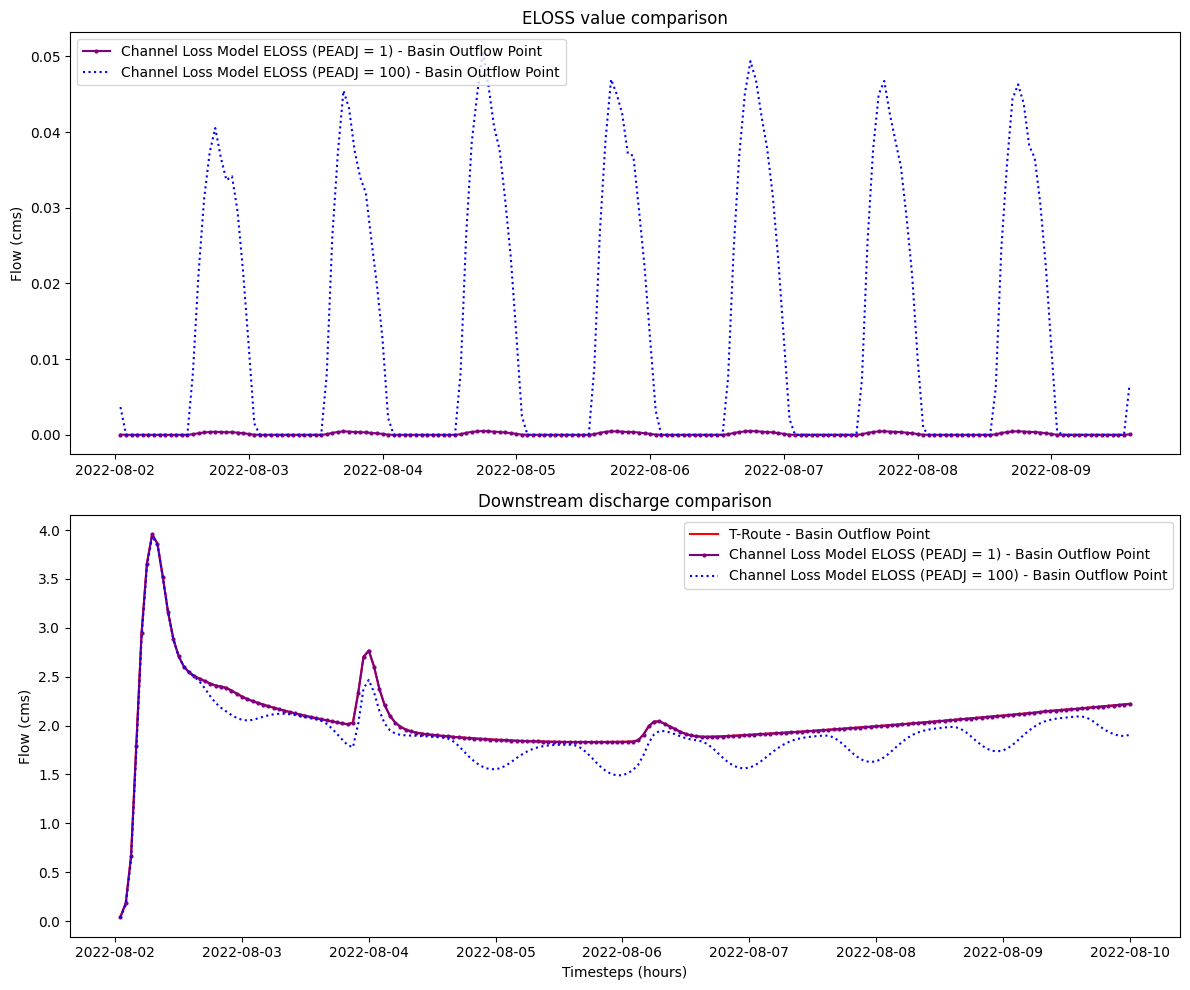

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(eloss_vals_base_df["datetime"], eloss_vals_base_df["value"], color="purple", label="Channel Loss Model ELOSS (PEADJ = 1) - Basin Outflow Point", marker='o', markersize=2, linestyle='-')
axes[0].plot(eloss_vals_high_df["datetime"], eloss_vals_high_df["value"], color="blue", label="Channel Loss Model ELOSS (PEADJ = 100) - Basin Outflow Point", linestyle=':')
axes[0].set_ylabel("Flow (cms)")
axes[0].set_title("ELOSS value comparison")
axes[0].legend()

axes[1].plot(df.index, df["flow"], color="red", label="T-Route - Basin Outflow Point")
axes[1].plot(df_base_eloss.index, df_base_eloss["flow"], color="purple", label="Channel Loss Model ELOSS (PEADJ = 1) - Basin Outflow Point", marker='o', markersize=2, linestyle='-')
axes[1].plot(df_high_eloss.index, df_high_eloss["flow"], color="blue", label="Channel Loss Model ELOSS (PEADJ = 100) - Basin Outflow Point", linestyle=':')
axes[1].set_ylabel("Flow (cms)")
axes[1].set_xlabel("Timesteps (hours)")
axes[1].set_title("Downstream discharge comparison")
axes[1].legend()

plt.tight_layout()
plt.show()


Conclusion: You can see the ET values obtained by the Evapotranspiration module fluxate based on what time of day it is. Additionally, the usage of a PEADJ factor can scale this ET and can potentially be calibrated

#### Examining SSOUT

Next, we'll examine the differences between running with and without the SSOUT values. Two different SSOUT values are shown to denonstrate how the adjustment setting is used.

In [8]:
# Load t-route output datasets for 
ds = xr.open_dataset("./output/base_output/troute_output_202208020000.nc", engine="netcdf4")
ds_base_ssout = xr.open_dataset("./output/ssout_base/troute_output_202208020000.nc", engine="netcdf4") 
ds_high_ssout = xr.open_dataset("./output/ssout_high/troute_output_202208020000.nc", engine="netcdf4")


In [9]:
# Process channel loss (ET) stream data at the downstream-most nexus
df_base_ssout = ds_base_ssout.sel(feature_id=2619318).to_dataframe().reset_index()
df_base_ssout["time"] = pd.to_datetime(df_base_ssout["time"])
df_base_ssout = df_base_ssout.set_index("time")
df_base_ssout["flow"] = df_base_ssout["flow"] * 0.028316846592 # convert to cms

df_high_ssout = ds_high_ssout.sel(feature_id=2619318).to_dataframe().reset_index()
df_high_ssout["time"] = pd.to_datetime(df_high_ssout["time"])
df_high_ssout = df_high_ssout.set_index("time")
df_high_ssout["flow"] = df_high_ssout["flow"] * 0.028316846592 # convert to cms


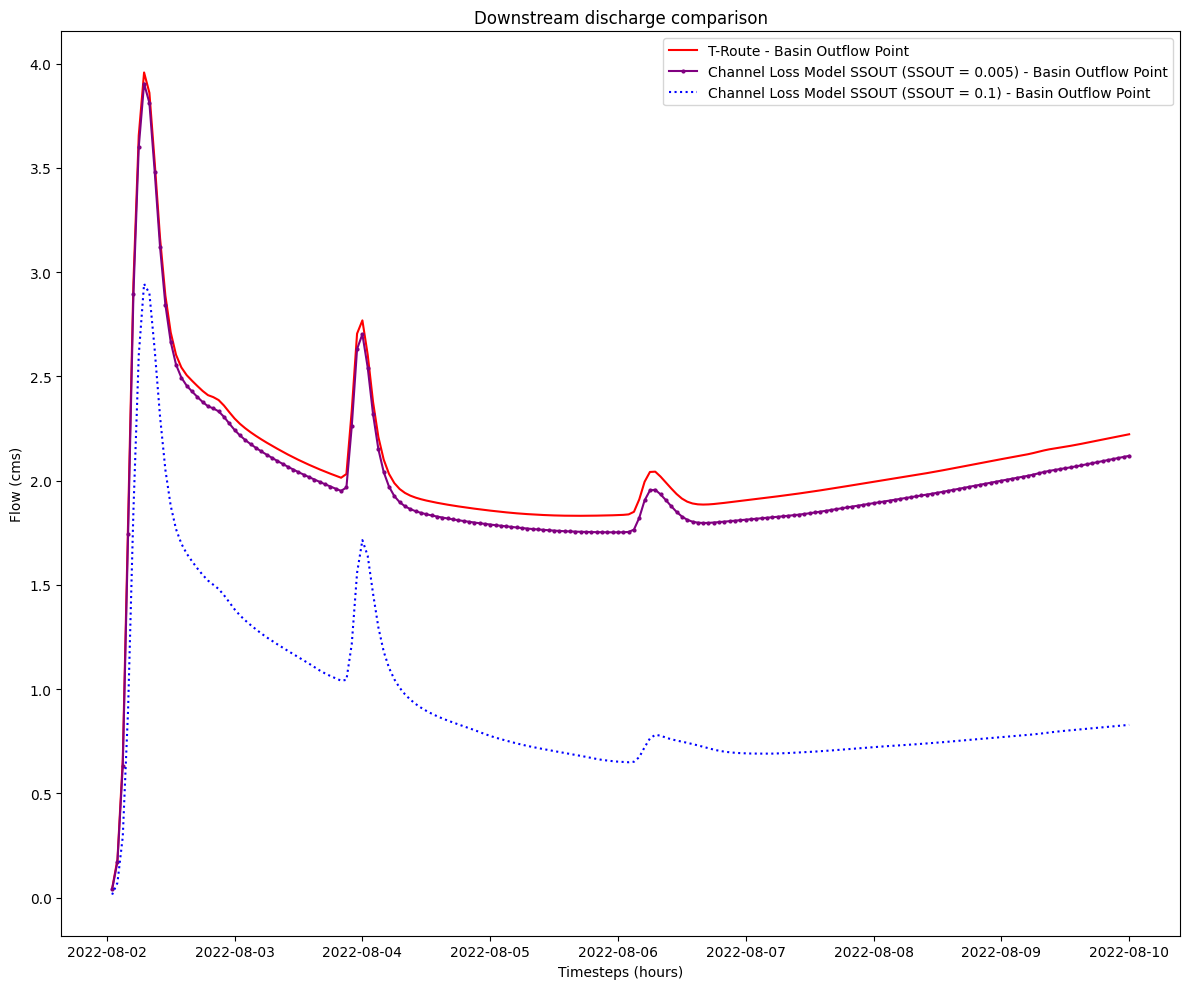

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(12, 10))

axes.plot(df.index, df["flow"], color="red", label="T-Route - Basin Outflow Point")
axes.plot(df_base_ssout.index, df_base_ssout["flow"], color="purple", label="Channel Loss Model SSOUT (SSOUT = 0.005) - Basin Outflow Point", marker='o', markersize=2, linestyle='-')
axes.plot(df_high_ssout.index, df_high_ssout["flow"], color="blue", label="Channel Loss Model SSOUT (SSOUT = 0.1) - Basin Outflow Point", linestyle=':')
axes.set_ylabel("Flow (cms)")
axes.set_xlabel("Timesteps (hours)")
axes.set_title("Downstream discharge comparison")
axes.legend()

plt.tight_layout()
plt.show()


Conclusions: you can see how the SSOUT value shift the hydrograph directly downward as a result of a constant infiltration factor. In the future, `INFILTRATION_EXCESS` values from NGEN can be used as a more accurate version of SSOUT, or this value can be calibrated to tune results